# Fashion-MNIST Classifier — PyTorch Refresher

An intermediate-level project to review the full PyTorch workflow: `Dataset`/`DataLoader`, building a CNN with `nn.Module`, training loops, GPU usage, evaluation, and model saving.

**Dataset:** Fashion-MNIST, loaded directly via `torchvision.datasets.FashionMNIST` (no manual download needed).

Work through each section, run the cells, and read the comments — they explain *why* each piece is there, not just *what* it does.

## 1. Imports and device setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

# Automatically use GPU if available, otherwise fall back to CPU.
# This pattern will appear in basically every PyTorch project you write.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## 2. Loading the data

`torchvision.datasets.FashionMNIST` downloads and prepares the dataset automatically. We wrap it in a `DataLoader`, which handles batching, shuffling, and (optionally) parallel loading for us — this is the standard pattern you'll use for any dataset in PyTorch.

We normalize pixel values to have mean 0 and std 1 (using the known Fashion-MNIST statistics), which generally helps training converge faster and more reliably.

In [2]:
# Fashion-MNIST mean/std (precomputed over the training set)
transform = transforms.Compose([
    transforms.ToTensor(),           # converts PIL image [0,255] -> tensor [0,1]
    transforms.Normalize((0.2860,), (0.3530,))  # normalize to mean 0, std 1
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Training samples: 60000
Test samples: 10000


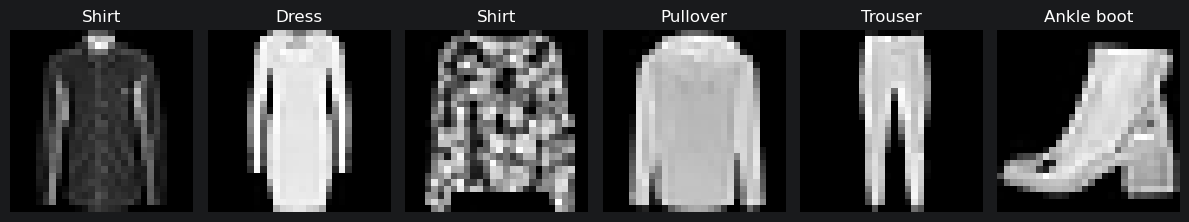

In [3]:
# Class labels for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Quick sanity check: visualize a few training images
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i in range(6):
    img = images[i].squeeze().numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis('off')
plt.tight_layout()
plt.show()


## 3. Defining the model

A small CNN: two convolutional blocks (Conv2d -> ReLU -> MaxPool2d) followed by two fully connected layers. This is a standard, minimal architecture — enough to get good accuracy on Fashion-MNIST without needing a GPU cluster.

Things to pay attention to here:
- `nn.Module` subclassing: `__init__` defines the layers, `forward` defines how data flows through them.
- How the spatial dimensions shrink after each `MaxPool2d`, and why the input size to the first `nn.Linear` layer has to match that (28 -> 14 -> 7).

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Block 1: 1 input channel (grayscale) -> 32 feature maps
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        # Block 2: 32 -> 64 feature maps
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # halves spatial size each time
        self.relu = nn.ReLU()

        # After two poolings: 28x28 -> 14x14 -> 7x7, with 64 channels
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.25)  # helps reduce overfitting

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # -> [batch, 32, 14, 14]
        x = self.pool(self.relu(self.conv2(x)))   # -> [batch, 64, 7, 7]

        x = torch.flatten(x, start_dim=1)         # -> [batch, 64*7*7]

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                           # raw logits (no softmax here)
        return x

model = SimpleCNN().to(device)
print(model)


SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


In [5]:
# Quick sanity check: count trainable parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")


Trainable parameters: 421,642


## 4. Loss function and optimizer

- `nn.CrossEntropyLoss` expects **raw logits** (not softmax probabilities) as input — it applies `log_softmax` internally for numerical stability. This is why `forward()` above returns raw logits, not probabilities.
- `Adam` is a solid default optimizer for this kind of task — adapts the learning rate per parameter, generally converges faster than plain SGD without much tuning.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


## 5. Training loop

The core cycle you'll reuse in almost every PyTorch project:

1. Forward pass — compute predictions
2. Compute the loss
3. `optimizer.zero_grad()` — clear old gradients (same idea as `p.grad = 0.0` in micrograd!)
4. `loss.backward()` — compute new gradients via autograd
5. `optimizer.step()` — update the weights

We track loss and accuracy per epoch so we can plot the training curve afterward.

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()  # enables dropout, batchnorm update, etc.
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [8]:
def evaluate(model, loader, criterion, device):
    model.eval()  # disables dropout, uses running stats for batchnorm
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # no need to track gradients during evaluation
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [9]:
NUM_EPOCHS = 8

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
          f"Test loss: {test_loss:.4f}, acc: {test_acc:.4f}")


Epoch 1/8 | Train loss: 0.4335, acc: 0.8436 | Test loss: 0.3160, acc: 0.8832
Epoch 2/8 | Train loss: 0.2878, acc: 0.8952 | Test loss: 0.2698, acc: 0.8997
Epoch 3/8 | Train loss: 0.2420, acc: 0.9119 | Test loss: 0.2472, acc: 0.9125
Epoch 4/8 | Train loss: 0.2142, acc: 0.9207 | Test loss: 0.2418, acc: 0.9111
Epoch 5/8 | Train loss: 0.1895, acc: 0.9305 | Test loss: 0.2324, acc: 0.9165
Epoch 6/8 | Train loss: 0.1692, acc: 0.9370 | Test loss: 0.2358, acc: 0.9202
Epoch 7/8 | Train loss: 0.1501, acc: 0.9442 | Test loss: 0.2562, acc: 0.9145
Epoch 8/8 | Train loss: 0.1336, acc: 0.9495 | Test loss: 0.2307, acc: 0.9236


## 6. Visualizing training curves

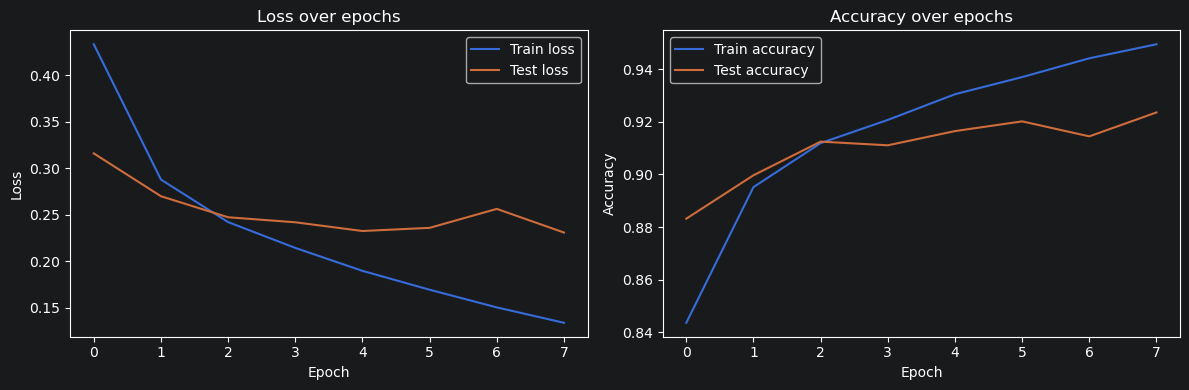

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['test_loss'], label='Test loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over epochs')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train accuracy')
axes[1].plot(history['test_acc'], label='Test accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Confusion matrix

Useful for seeing *which* classes get confused with each other — for Fashion-MNIST, expect some confusion between visually similar classes like "Shirt", "T-shirt/top", "Pullover", and "Coat".

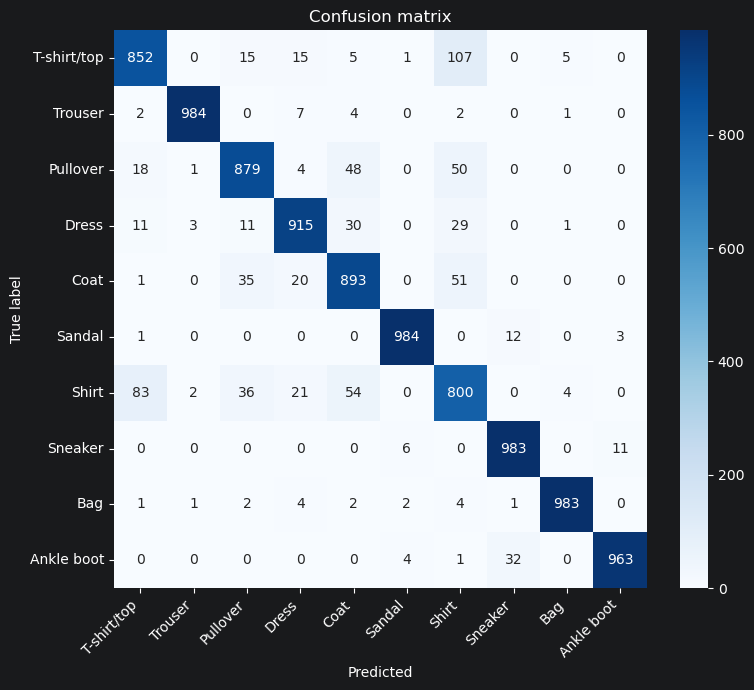

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True label')
plt.title('Confusion matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 8. Visualizing predictions

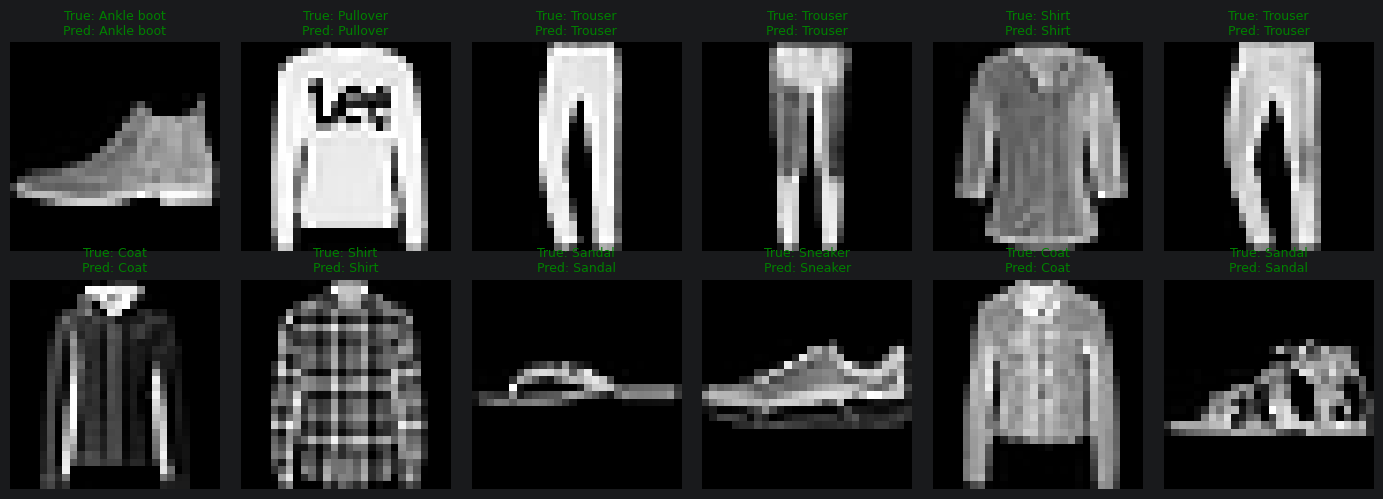

In [12]:
images, labels = next(iter(test_loader))
images_device = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images_device)
    _, preds = torch.max(outputs, dim=1)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]
    color = 'green' if labels[i] == preds[i] else 'red'

    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


## 9. Saving and loading the model

It's essential in any real project — you don't want to retrain from scratch every time you want to use your model.

In [13]:
# Save just the learned weights (recommended approach)
torch.save(model.state_dict(), 'fashion_mnist_cnn.pth')
print("Model saved to fashion_mnist_cnn.pth")


Model saved to fashion_mnist_cnn.pth


In [15]:
# Loading it back (e.g. in a new session): recreate the architecture first,
# then load the saved weights into it.
loaded_model = SimpleCNN().to(device)
loaded_model.load_state_dict(torch.load('fashion_mnist_cnn.pth', map_location=device, weights_only=True))
loaded_model.eval()

# Quick check that it gives the same results as the original model
test_loss, test_acc = evaluate(loaded_model, test_loader, criterion, device)
print(f"Loaded model — test loss: {test_loss:.4f}, test acc: {test_acc:.4f}")


Loaded model — test loss: 0.2307, test acc: 0.9236


## Next steps (optional extensions)

This are natural ways to push further with the project:

1. **Data augmentation**: add `transforms.RandomHorizontalFlip()` or `RandomRotation()` to the training transform and compare accuracy.
2. **Monte Carlo Dropout for uncertainty**: keep `model.train()` active during inference (so dropout stays on), run the same image through the model multiple times, and look at the variance across predictions — a simple, concrete first taste of uncertainty estimation before moving to diffusion models.
3. **Try a deeper architecture**: add a third conv block, or experiment with batch normalization (`nn.BatchNorm2d`) between conv and activation.
4. **Learning rate scheduling**: add `torch.optim.lr_scheduler.StepLR` and see how it affects convergence.